In [15]:
import json
import numpy as np
import xobjects as xo
import xtrack as xt
import xpart as xp
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy import constants 
####################
# Choose a context #
####################
context = xo.ContextCpu(omp_num_threads=4)
# context = xo.ContextCpu(omp_num_threads='auto')


#references: https://www.sciencedirect.com/science/article/pii/S0168900222011445?ref=pdf_download&fr=RR-2&rr=80ca25af8a5ace93

# Ion properties:
m_u = 931.49410242e6 # eV/c^2 -- atomic mass unit
A = 16 # Weight of O
#Z = 6  # Number of protons in the ion (O)
#m_e = 0.511e6 # eV/c^2 -- electron mass
m_p = 938.272088e6 # eV/c^2 -- proton mass
clight = 299792458.0 # m/s

q0=5

mass0 = A*m_u #+ Ne*m_e # eV/c^2

beta_rel = 0.64
gamma_rel = 1.30

p0c = mass0*beta_rel*gamma_rel #eV/c

# equiv_proton_momentum = 236e9 # eV/c = gamma_p*m_p*v
# gamma_p = np.sqrt( 1 + (equiv_proton_momentum/m_p)**2 ) # equvalent gamma for protons in the ring

# p0c = equiv_proton_momentum*(Z-Ne) # eV/c
gamma2 = np.sqrt( 1 + (p0c/mass0)**2 ) # ion relativistic factor
beta2 = np.sqrt(1-1/(gamma2*gamma2)) # ion beta

circumference =  128.80 #m
T = circumference/(clight*beta_rel)
s_per_turn = T
slip_factor=0.45

beta_x = 6
beta_y = 2

disp_x = 0
Q_x = 2.2
Q_y = 2.4
dQx = 0
dQy = 0

arc = xt.LineSegmentMap(
        qx=Q_x, qy=Q_y,
        dqx=dQx, dqy=dQy,
        length=circumference,
        betx=beta_x,
        bety=beta_y
        )

emittance_x=10*1e-6 #inital emittance
emittance_y=15*1e-6 #inital emittance
num_particles = int(1e4)

sigma_x = np.sqrt(beta_x*emittance_x)
sigma_px = np.sqrt(emittance_x*1/beta_x)
sigma_y = np.sqrt(beta_y*emittance_y)
sigma_py = np.sqrt(emittance_y*1/beta_y)
# sigma_p = 2e-5 # relative ion momentum spread
# sigma_p = 2e-4 # relative ion momentum spread

delta = np.linspace(-9.2e-5, 9.2e-5, num_particles)
delta = np.linspace(0, 1e-5, num_particles)

# delta = np.random.normal(loc=0, scale=sigma_p, size=num_particles)
x = np.random.normal(loc=0.0, scale=sigma_x, size=num_particles) + disp_x * delta
px = np.random.normal(loc=0.0, scale=sigma_px, size=num_particles)
y = np.random.normal(loc=0.0, scale=sigma_y, size=num_particles)
py = np.random.normal(loc=0.0, scale=sigma_py, size=num_particles)

particles = xp.Particles(
    mass0=mass0,
    p0c=p0c,
    q0=q0,
    x=x*0,
    px=px*0,
    y=y*0,
    py=py*0,
    delta=delta,
    zeta=0
)
particles._init_random_number_generator()

##################
# Laser Cooler #
##################

#laser-ion beam collision angle
theta_l = 2.6*np.pi/180 # rad
theta_l = 0
nx = 0; ny = -np.sin(theta_l); nz = -np.cos(theta_l)

# Ion excitation energy:
# hw0 = 230.823 # eV
hc=constants.hbar*clight/constants.e # eV*m (ħc)
lambda_0 = 103.76*1e-9 # m -- ion excitation wavelength
hw0 = 2*np.pi*hc/lambda_0 # eV -- ion excitation energy
ion_excited_lifetime=2.44e-9


lambda_l = lambda_0*gamma_rel*(1 + beta_rel*np.cos(theta_l)) # m -- laser wavelength
# Shift laser wavelength for fast longitudinal cooling:
# lambda_l = lambda_l*(1+1*sigma_p)
# lambda_l = 2.213116311631163e-07
lambda_l = 2.2130563056305633e-07 #target 5e-6
#lambda_l = lambda_l*(1+1*sigma_p) # m

laser_frequency = clight/lambda_l # Hz


# laser_waist_radius = 5*1e-3
# laser_waist_radius = 1000*1e-3

laser_power=40*1e-3 #W
laser_waist_radius = 5*1e-3
laser_area=np.pi*(laser_waist_radius*laser_waist_radius)

# laser_waist_radius = 1000*1e-3
# laser_intensity=200000
# laser_intensity=12732.395447351628
laser_intensity=laser_power/laser_area

cooling_section_length=25
GF_IP = xt.CWLaser(
                      laser_x=0,
                      laser_y=0,
                      laser_z=0,
                      
                      laser_direction_nx = 0,
                      laser_direction_ny = 0,
                      laser_direction_nz = -1,
                      laser_wavelength = lambda_l, # m
                      laser_waist_radius = laser_waist_radius, # m
                      laser_intensity=laser_intensity,
                      ion_excitation_energy = hw0, # eV
                      ion_excited_lifetime  = ion_excited_lifetime, # sec
                      cooling_section_length=cooling_section_length
                          
   )

# ##################
# # Tracking #
# ##################

# simulation parameters: simulate 10 s of cooling, and take data once every 100 ms
T_per_turn = circumference/(clight*beta_rel)


num_turns = int(103.6*1e4) #103.6*1e6
num_turns = int(103.6*1e4) #103.6*1e6
num_turns = int(1e5) # 0 emittance
save_interval=num_turns/100

# create a monitor object, to reduce holded data
monitor = xt.ParticlesMonitor(start_at_turn=0, stop_at_turn=1,
                              n_repetitions=int(num_turns/save_interval),
                              repetition_period=save_interval,
                              num_particles=num_particles)

line = xt.Line(
        elements=[monitor,GF_IP, arc])

particle_ref = xp.Particles(mass0=mass0, q0=q0, p0c=p0c)

line.particle_ref = particle_ref
line.build_tracker(_context=context)


line.track(particles, num_turns=num_turns,
              turn_by_turn_monitor=False,with_progress=True)

# extract relevant values
x = monitor.x[:,:,0]
px = monitor.px[:,:,0]
y = monitor.y[:,:,0]
py = monitor.py[:,:,0]
delta = monitor.delta[:,:,0]
zeta = monitor.zeta[:,:,0]
accumulated_length=monitor.s[:,:,0]
state = monitor.state[:,:,0]
time = monitor.at_turn[:, 0, 0] * T_per_turn

excited=particles.state==2
excited = excited.astype(int)
fraction_excitation = sum(excited)/len(excited)
time = np.arange(0, num_turns, save_interval) * s_per_turn

# Extract delta at the first turn (assuming the first turn is at index 0)
delta_first_turn = delta[0, :]

# Extract delta at the final turn
delta_final_turn = delta[-1, :]

# --- Define Histogram Parameters ---
# Choose bins that span the expected range of delta. Adjust as needed.
bins = np.linspace(0, 1e-5, 51)  # 50 bins between 0 and 1e-5

# --- Compute Histograms ---
hist_before, bin_edges = np.histogram(delta_first_turn, bins=bins)
hist_after, _ = np.histogram(delta_final_turn, bins=bins)

# Calculate the bin centers for later use:
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# --- Find Maximum Bin Heights ---
max_bin_height_before = np.max(hist_before)
max_bin_height_after = np.max(hist_after)

print(f"Max bin height (before cooling): {max_bin_height_before}")
print(f"Max bin height (after cooling):  {max_bin_height_after}")

# --- Find the Minimum Bin in the "After Cooling" Histogram ---
# This finds the index of the minimum count in the final (after) distribution
min_index_after = np.argmin(hist_after)
min_bin_center_after = bin_centers[min_index_after]
min_bin_count_after = hist_after[min_index_after]

print(f"Minimum bin count (after cooling): {min_bin_count_after}")
print(f"Location of minimum bin (after cooling) (bin center): {min_bin_center_after:.2e}")

assert max_bin_height_after > 1.5*max_bin_height_before


Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


Tracking: 100%|██████████| 100000/100000 [00:40<00:00, 2496.68it/s]

Max bin height (before cooling): 200
Max bin height (after cooling):  364
Minimum bin count (after cooling): 12
Location of minimum bin (after cooling) (bin center): 4.10e-06


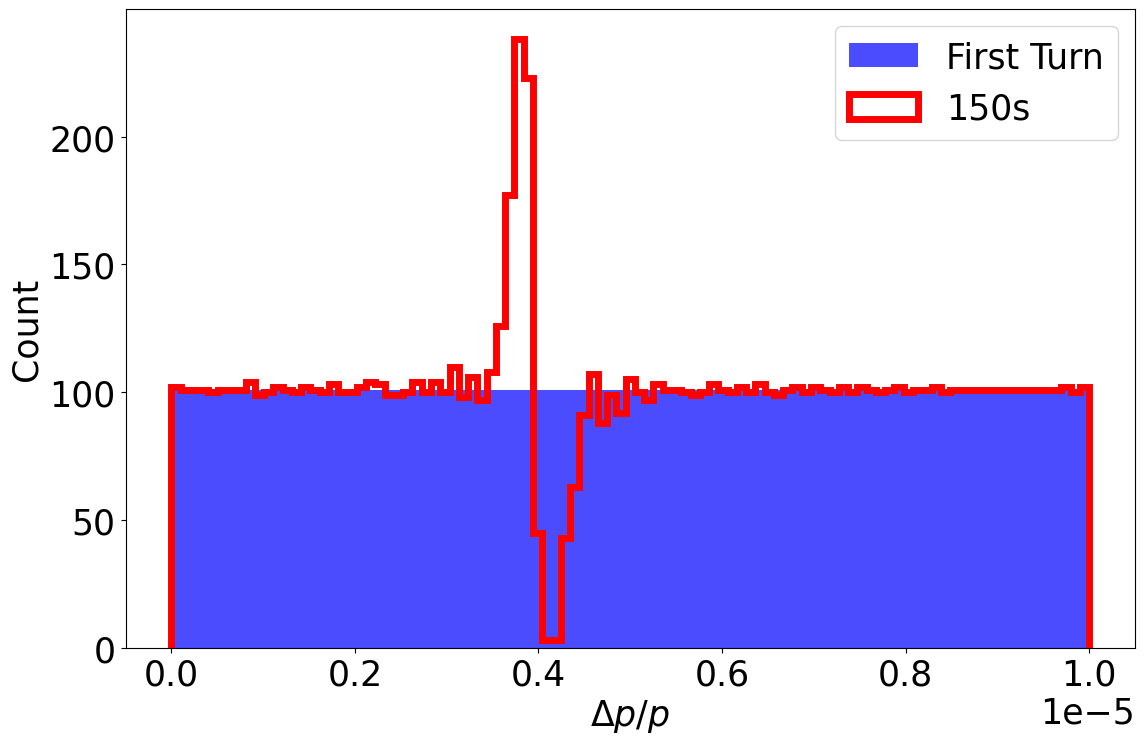

In [16]:

min_delta=min(delta_final_turn)
max_delta=max(delta_final_turn)
bins = np.linspace(min_delta, max_delta, 100)
# Plotting for final turn
plt.figure(figsize=(12, 8))
plt.rcParams.update({'font.size': 25})
plt.hist(delta_first_turn, bins=bins, color='blue', alpha=0.7, label='First Turn', linewidth=5)
plt.hist(delta_final_turn, bins=bins, color='red', alpha=1, label='150s', histtype='step', linewidth=5)
plt.xlabel(r'$\Delta p/p$')
plt.ylabel('Count')
plt.legend()
plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
plt.tight_layout()
plt.show()

In [17]:
max(delta_first_turn)

np.float64(1e-05)

In [18]:
max(delta_final_turn)

np.float64(1e-05)